# ENTRENAMIENTO DEL DATASET DE OBRA

### PASO 1 — Cargar el dataset parquet limpio y listo para entrenamiento

In [19]:
# ============================================================
# PASO 1 — CONFIGURACIÓN Y CARGA DEL DATASET
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# RUTAS
# ------------------------------------------------------------

BASE_DIR = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

DATA_PROC = BASE_DIR / "data" / "processed"

print("BASE_DIR :", BASE_DIR)
print("DATA_PROC:", DATA_PROC)

# ------------------------------------------------------------
# CARGAR DATASET FINAL DE OBRA
# ------------------------------------------------------------

dataset_path = DATA_PROC / "dataset_obra_v4_model.parquet"

df = pd.read_parquet(dataset_path)

# ------------------------------------------------------------
# VALIDACIÓN BÁSICA
# ------------------------------------------------------------

print("\n" + "="*70)
print("DATASET CARGADO")
print("="*70)

print("Shape:", df.shape)

print("\nColumnas:")
for i, c in enumerate(df.columns, 1):
    print(f"{i:02d}. {c}")

print("\nPrimeras filas:")
display(df.head())

BASE_DIR : C:\IA_Investigacion\Deteccion_Corrupcion
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed

DATASET CARGADO
Shape: (326, 33)

Columnas:
01. IDENTIFICADOR_OBRA
02. y_riesgo_obra_5niveles
03. obra_n_miembros_comite
04. obra_n_dnis_comite_unicos
05. obra_n_convocatorias_comite
06. obra_n_procesos_comite
07. obra_ratio_repeticion_comite
08. obra_n_participaciones
09. obra_n_rucs_participantes
10. obra_n_contratos
11. obra_n_codigos_obra
12. obra_n_procesos
13. obra_ratio_participacion
14. obra_ratio_contrato_participacion
15. obra_monto_ofertado_mean
16. obra_monto_ofertado_std
17. obra_monto_ofertado_min
18. obra_monto_ofertado_max
19. obra_n_ofertas
20. obra_rango_ofertas
21. obra_cv_ofertas
22. obra_planificado_mean
23. obra_real_mean
24. obra_planificado_max
25. obra_real_max
26. obra_n_registros_ejecucion
27. obra_n_anhos
28. obra_n_meses
29. obra_ratio_real_plan
30. obra_desviacion_real_plan
31. obra_planificado_cero
32. obra_real_cero
33. obra_sin_ejecuci

,IDENTIFICADOR_OBRA,y_riesgo_obra_5niveles,obra_n_miembros_comite,obra_n_dnis_comite_unicos,obra_n_convocatorias_comite,obra_n_procesos_comite,obra_ratio_repeticion_comite,obra_n_participaciones,obra_n_rucs_participantes,obra_n_contratos,...,obra_planificado_max,obra_real_max,obra_n_registros_ejecucion,obra_n_anhos,obra_n_meses,obra_ratio_real_plan,obra_desviacion_real_plan,obra_planificado_cero,obra_real_cero,obra_sin_ejecucion
0,2002060-2434-702592-2064311-19777,4,6.0,6.0,1.0,1.0,1.0,6.0,6.0,1.0,...,0.0,0.0,1,0,0,NaN,0.0,1,1,1
1,2002210-8880-869397-2169938-826,2,6.0,6.0,1.0,1.0,1.0,14.0,14.0,1.0,...,0.0,0.0,1,0,0,NaN,0.0,1,1,1
2,2002210-8880-870112-2169901-826,2,6.0,6.0,1.0,1.0,1.0,13.0,13.0,1.0,...,0.0,0.0,1,0,0,NaN,0.0,1,1,1
3,2015918-1249-721938-2074791-45660,4,6.0,6.0,1.0,1.0,1.0,NaN,NaN,NaN,...,0.0,0.0,1,0,0,NaN,0.0,1,1,1
4,2026767-16256-709096-2067605-143536,4,6.0,6.0,1.0,1.0,1.0,20.0,10.0,1.0,...,0.0,0.0,1,0,0,NaN,0.0,1,1,1


### Paso 2 - Limpieza pre-modelo

In [20]:
# ============================================================
# PASO 2 — LIMPIEZA PRE-MODELO
# ============================================================

TARGET = "y_riesgo_obra_5niveles"

# Columnas que NO deben entrar al modelo
cols_excluir = [
    "IDENTIFICADOR_OBRA",        # llave técnica
    "RIESGO_DESCRIPCION_OBRA",   # leakage textual del target
]

# Validar target
if TARGET not in df.columns:
    raise ValueError(f"No existe el target: {TARGET}")

# Separar X / y
X = df.drop(columns=cols_excluir + [TARGET], errors="ignore").copy()
y = df[TARGET].astype(int).copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribución del target:")
display(
    y.value_counts()
    .sort_index()
    .to_frame("cantidad")
)

print("\nDistribución porcentual:")
display(
    (y.value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame("porcentaje")
)

Shape X: (326, 31)
Shape y: (326,)

Distribución del target:


,cantidad
y_riesgo_obra_5niveles,
0,32
1,52
2,87
3,7
4,148



Distribución porcentual:


,porcentaje
y_riesgo_obra_5niveles,
0,9.82
1,15.95
2,26.69
3,2.15
4,45.40


In [21]:
# ============================================================
# VALIDACIÓN DE COLUMNAS Y NULOS
# ============================================================

print("=" * 80)
print("COLUMNAS DE X")
print("=" * 80)

for i, c in enumerate(X.columns, 1):
    print(f"{i:02d}. {c} | {X[c].dtype}")

print("\nColumnas con nulos:")
display(
    X.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("n_nulos")
    .query("n_nulos > 0")
)

# Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNuméricas:", len(num_cols))
print(num_cols)

print("\nCategóricas:", len(cat_cols))
print(cat_cols)

COLUMNAS DE X
01. obra_n_miembros_comite | float64
02. obra_n_dnis_comite_unicos | float64
03. obra_n_convocatorias_comite | float64
04. obra_n_procesos_comite | float64
05. obra_ratio_repeticion_comite | float64
06. obra_n_participaciones | float64
07. obra_n_rucs_participantes | float64
08. obra_n_contratos | float64
09. obra_n_codigos_obra | float64
10. obra_n_procesos | float64
11. obra_ratio_participacion | float64
12. obra_ratio_contrato_participacion | float64
13. obra_monto_ofertado_mean | float64
14. obra_monto_ofertado_std | float64
15. obra_monto_ofertado_min | float64
16. obra_monto_ofertado_max | float64
17. obra_n_ofertas | float64
18. obra_rango_ofertas | float64
19. obra_cv_ofertas | float64
20. obra_planificado_mean | float64
21. obra_real_mean | float64
22. obra_planificado_max | float64
23. obra_real_max | float64
24. obra_n_registros_ejecucion | int64
25. obra_n_anhos | int64
26. obra_n_meses | int64
27. obra_ratio_real_plan | float64
28. obra_desviacion_real_plan |

,n_nulos
obra_ratio_real_plan,256
obra_cv_ofertas,74
obra_monto_ofertado_std,74
obra_n_procesos_comite,67
obra_ratio_repeticion_comite,67
obra_n_dnis_comite_unicos,67
obra_n_miembros_comite,67
obra_n_convocatorias_comite,67
obra_n_contratos,2
obra_n_rucs_participantes,2



Numéricas: 31
['obra_n_miembros_comite', 'obra_n_dnis_comite_unicos', 'obra_n_convocatorias_comite', 'obra_n_procesos_comite', 'obra_ratio_repeticion_comite', 'obra_n_participaciones', 'obra_n_rucs_participantes', 'obra_n_contratos', 'obra_n_codigos_obra', 'obra_n_procesos', 'obra_ratio_participacion', 'obra_ratio_contrato_participacion', 'obra_monto_ofertado_mean', 'obra_monto_ofertado_std', 'obra_monto_ofertado_min', 'obra_monto_ofertado_max', 'obra_n_ofertas', 'obra_rango_ofertas', 'obra_cv_ofertas', 'obra_planificado_mean', 'obra_real_mean', 'obra_planificado_max', 'obra_real_max', 'obra_n_registros_ejecucion', 'obra_n_anhos', 'obra_n_meses', 'obra_ratio_real_plan', 'obra_desviacion_real_plan', 'obra_planificado_cero', 'obra_real_cero', 'obra_sin_ejecucion']

Categóricas: 0
[]


In [22]:
# ============================================================
# VALIDACIÓN ANTI-LEAKAGE / ANTI-ID
# ============================================================

forbidden_exact = [
    "DNI",
    "RUC",
    "CODIGO_DNI",
    "CODIGO_RUC",
    "NOMBRE",
    "RAZON_SOCIAL",
]

bad_cols = []

for col in X.columns:

    col_upper = col.upper()

    # Permitir columnas agregadas tipo:
    # obra_n_dnis_comite_unicos
    # obra_n_rucs_participantes

    if (
        col_upper == "DNI"
        or col_upper == "RUC"
        or col_upper.startswith("CODIGO_DNI")
        or col_upper.startswith("CODIGO_RUC")
        or col_upper.startswith("NOMBRE")
        or col_upper.startswith("RAZON_SOCIAL")
    ):
        bad_cols.append(col)

print("Columnas sospechosas:", bad_cols)

if bad_cols:
    raise ValueError(
        f"Revisar columnas sospechosas antes de entrenar: {bad_cols}"
    )
else:
    print("✅ Validación OK")

Columnas sospechosas: []
✅ Validación OK


Los identificadores directos fueron excluidos del modelo; sin embargo, se conservaron variables agregadas derivadas, tales como cantidades y ratios, debido a su capacidad para representar patrones estructurales y relacionales sin exponer identidades individuales

### Paso 3 — Split estratificado train/test

In [23]:
# ============================================================
# PASO 3 — SPLIT TRAIN / TEST ESTRATIFICADO
# ============================================================

from sklearn.model_selection import train_test_split

TEST_SIZE = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribución y_train:")
display(
    y_train.value_counts()
    .sort_index()
    .to_frame("cantidad")
)

print("\nDistribución y_test:")
display(
    y_test.value_counts()
    .sort_index()
    .to_frame("cantidad")
)

X_train: (260, 31)
X_test : (66, 31)
y_train: (260,)
y_test : (66,)

Distribución y_train:


,cantidad
y_riesgo_obra_5niveles,
0,26
1,41
2,69
3,6
4,118



Distribución y_test:


,cantidad
y_riesgo_obra_5niveles,
0,6
1,11
2,18
3,1
4,30


In [24]:
# ============================================================
# VALIDAR PROPORCIÓN POR CLASE
# ============================================================

dist_compare = pd.DataFrame({
    "total_pct": y.value_counts(normalize=True).sort_index(),
    "train_pct": y_train.value_counts(normalize=True).sort_index(),
    "test_pct": y_test.value_counts(normalize=True).sort_index(),
}).fillna(0) * 100

display(dist_compare.round(2))

,total_pct,train_pct,test_pct
y_riesgo_obra_5niveles,,,
0,9.82,10.00,9.09
1,15.95,15.77,16.67
2,26.69,26.54,27.27
3,2.15,2.31,1.52
4,45.40,45.38,45.45


##### Nota importante.
La Clase 3 es muy baja (riesgo ), en una siguiente iteración puede agruparse con 2 o con 4, se sugiere con 2.

### PASO 4 — PREPROCESADOR

In [25]:
# ============================================================
# PASO 4 — PREPROCESADOR COMÚN PARA LOS MODELOS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# Columnas numéricas y categóricas
# ------------------------------------------------------------

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numéricas:", len(num_cols))
print(num_cols)

print("\nCategóricas:", len(cat_cols))
print(cat_cols)

# ------------------------------------------------------------
# Pipeline numérico
# ------------------------------------------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# ------------------------------------------------------------
# Pipeline categórico
# ------------------------------------------------------------

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# Preprocesador general
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

print("\n✅ Preprocesador común construido")

Numéricas: 31
['obra_n_miembros_comite', 'obra_n_dnis_comite_unicos', 'obra_n_convocatorias_comite', 'obra_n_procesos_comite', 'obra_ratio_repeticion_comite', 'obra_n_participaciones', 'obra_n_rucs_participantes', 'obra_n_contratos', 'obra_n_codigos_obra', 'obra_n_procesos', 'obra_ratio_participacion', 'obra_ratio_contrato_participacion', 'obra_monto_ofertado_mean', 'obra_monto_ofertado_std', 'obra_monto_ofertado_min', 'obra_monto_ofertado_max', 'obra_n_ofertas', 'obra_rango_ofertas', 'obra_cv_ofertas', 'obra_planificado_mean', 'obra_real_mean', 'obra_planificado_max', 'obra_real_max', 'obra_n_registros_ejecucion', 'obra_n_anhos', 'obra_n_meses', 'obra_ratio_real_plan', 'obra_desviacion_real_plan', 'obra_planificado_cero', 'obra_real_cero', 'obra_sin_ejecucion']

Categóricas: 0
[]

✅ Preprocesador común construido


### PASO 5 — ENTRENAMIENTO

In [26]:
# ============================================================
# PASO 5 — ENTRENAMIENTO CON 3 ALGORITMOS
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )
}

results = []
trained_pipelines = {}

for name, clf in models.items():

    print("\n" + "=" * 80)
    print(f"ENTRENANDO: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    metrics = {
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
    }

    results.append(metrics)
    trained_pipelines[name] = pipe

    print("Métricas:")
    print(metrics)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(
    "macro_f1",
    ascending=False
)

display(results_df)


ENTRENANDO: RandomForest
Métricas:
{'modelo': 'RandomForest', 'accuracy': 0.5606060606060606, 'balanced_accuracy': 0.39676767676767677, 'macro_f1': 0.4082739156268568, 'weighted_f1': 0.5407855290876682}

Classification report:
              precision    recall  f1-score   support

           0       0.60      0.50      0.55         6
           1       0.60      0.27      0.38        11
           2       0.44      0.44      0.44        18
           3       0.00      0.00      0.00         1
           4       0.61      0.77      0.68        30

    accuracy                           0.56        66
   macro avg       0.45      0.40      0.41        66
weighted avg       0.55      0.56      0.54        66


Matriz de confusión:
[[ 3  0  0  0  3]
 [ 0  3  5  0  3]
 [ 0  1  8  0  9]
 [ 1  0  0  0  0]
 [ 1  1  5  0 23]]

ENTRENANDO: GradientBoosting
Métricas:
{'modelo': 'GradientBoosting', 'accuracy': 0.5454545454545454, 'balanced_accuracy': 0.3856565656565657, 'macro_f1': 0.402424242424

c:\IA_Investigacion\Deteccion_Corrupcion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,modelo,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,RandomForest,0.560606,0.396768,0.408274,0.540786
1,GradientBoosting,0.545455,0.385657,0.402424,0.528375
2,LogisticRegression,0.333333,0.270707,0.193287,0.295508


In [27]:
# ============================================================
# MEJOR MODELO SEGÚN MACRO F1
# ============================================================

best_model_name = results_df.iloc[0]["modelo"]
best_pipeline = trained_pipelines[best_model_name]

print("Mejor modelo:", best_model_name)

display(results_df)

Mejor modelo: RandomForest


,modelo,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,RandomForest,0.560606,0.396768,0.408274,0.540786
1,GradientBoosting,0.545455,0.385657,0.402424,0.528375
2,LogisticRegression,0.333333,0.270707,0.193287,0.295508


### Paso 6. Matriz de Confusión del mejor modelo

Matriz de confusión:
[[ 3  0  0  0  3]
 [ 0  3  5  0  3]
 [ 0  1  8  0  9]
 [ 1  0  0  0  0]
 [ 1  1  5  0 23]]


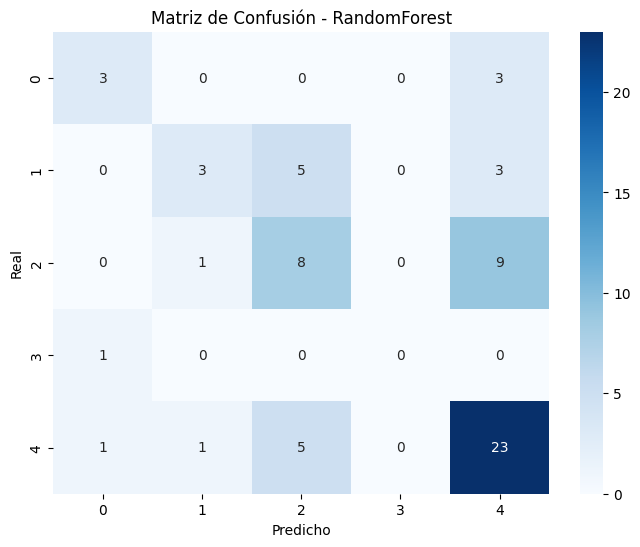

In [28]:
# ============================================================
# MATRIZ DE CONFUSIÓN — MEJOR MODELO
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predicción
y_pred_best = best_pipeline.predict(X_test)

# Matriz
cm = confusion_matrix(y_test, y_pred_best)

print("Matriz de confusión:")
print(cm)

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Matriz de Confusión - {best_model_name}")
plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

##### Datos Importantes:
* El modelo mostró una adecuada capacidad para identificar obras clasificadas como “Extremadamente Riesgosas”, alcanzando 23 predicciones correctas sobre dicha categoría, lo que evidencia la presencia de patrones diferenciables asociados al riesgo elevado de corrupción.
* El modelo confunde clases intermedias, las obras medianamente riesgosas comparten características con las extremadamente riesgosas.
* El modelo prácticamente no aprendió a predecir la clase 3. Se mantiene la sugerencia de unificarla con la clase 2 o 4, se hará la consulta al usuario.
* El modelo tiende hacia la Clase 4, tiene sesgo hacia la clase mayoritaria.

### SIGUIENTES PASOS
* Feature Importance RF
* Cross Validation
* Hyperparameter Tuning
* Integrar el Dataset Maestro (Obra, empresa, funcionario)


### PASO 7 — FEATURE IMPORTANCE (Random Forest)

,feature,importance
0,num__obra_monto_ofertado_mean,0.148277
1,num__obra_monto_ofertado_max,0.145458
2,num__obra_monto_ofertado_min,0.141782
3,num__obra_n_rucs_participantes,0.070176
4,num__obra_n_ofertas,0.066343
5,num__obra_ratio_contrato_participacion,0.065283
6,num__obra_n_participaciones,0.065165
7,num__obra_monto_ofertado_std,0.032774
8,num__obra_rango_ofertas,0.031727
9,num__obra_ratio_participacion,0.030769


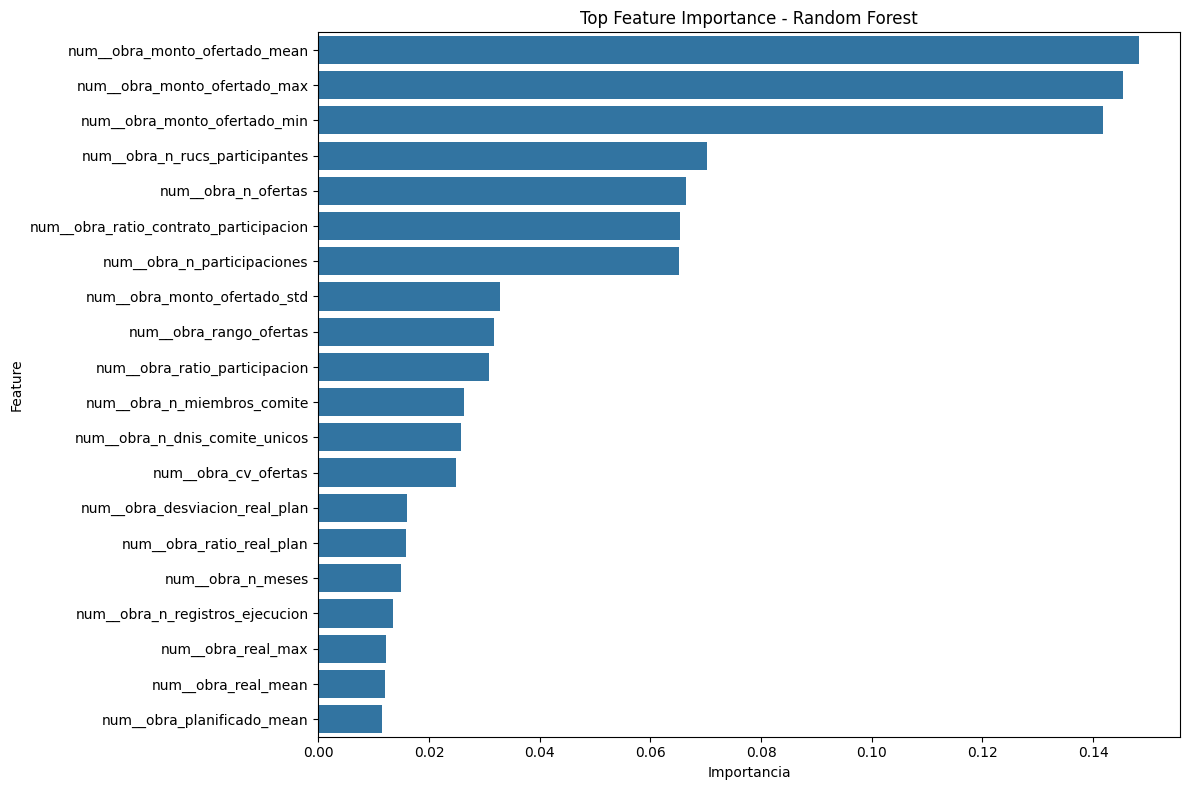

In [29]:
# ============================================================
# PASO 7 — FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Obtener modelo RF
# ------------------------------------------------------------

rf_model = trained_pipelines["RandomForest"]

# ------------------------------------------------------------
# Obtener nombres finales de features
# ------------------------------------------------------------

feature_names = rf_model.named_steps["prep"].get_feature_names_out()

# ------------------------------------------------------------
# Obtener importancias
# ------------------------------------------------------------

importances = rf_model.named_steps["model"].feature_importances_

# ------------------------------------------------------------
# DataFrame importance
# ------------------------------------------------------------

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi_df = fi_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Top 20
# ------------------------------------------------------------

TOP_N = 20

top_fi = fi_df.head(TOP_N)

display(top_fi)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_fi,
    x="importance",
    y="feature"
)

plt.title("Top Feature Importance - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

##### Resultado: 
El riesgo de corrupción está altamente relacionado con patrones económicos, competitivos y estructurales del proceso de contratación

Posibles explicaciones reales:
* Sobrevaloración. Obras con montos elevados podrían: atraer esquemas colusorios, facilitar sobrecostos y/o incrementar incentivos corruptos o inconducta funcional
* Concentración económica. Poca dispersión de ofertas puede indicar: baja competencia, direccionamiento, colusión.

Obras riesgosas podrían presentar:
* pocas empresas reales
* participantes repetidos
* baja competencia efectiva
* empresas recurrentes

La repetición o baja diversidad de miembros de comité podría estar asociada a mayores niveles de riesgo

### PASO 8 — CROSS VALIDATION

In [30]:
# ============================================================
# PASO 7 — CROSS VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models_cv = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

cv_results = []

for name, clf in models_cv.items():

    print("\n" + "=" * 80)
    print(f"CROSS VALIDATION: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", clf)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {
        "modelo": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "weighted_f1_std": scores["test_weighted_f1"].std(),
    }

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "macro_f1_mean",
    ascending=False
)

display(cv_results_df)


CROSS VALIDATION: RandomForest

CROSS VALIDATION: GradientBoosting

CROSS VALIDATION: LogisticRegression


,modelo,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,RandomForest,0.546154,0.068111,0.372461,0.047581,0.382839,0.066951,0.521935,0.071943
1,GradientBoosting,0.539767,0.021583,0.370659,0.023083,0.380228,0.022951,0.516468,0.020705
2,LogisticRegression,0.184289,0.087319,0.203073,0.038198,0.105412,0.048468,0.137020,0.096803


##### Resultado.
Aunque Random Forest obtuvo el mejor desempeño promedio, Gradient Boosting mostró menor variabilidad entre particiones, evidenciando mayor estabilidad y capacidad de generalización.

### PASO 9 — HYPERPARAMETER TUNING (RF)

In [34]:
# ============================================================
# PASO 9 — HYPERPARAMETER TUNING RF
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from scipy.stats import randint

# ------------------------------------------------------------
# Pipeline RF
# ------------------------------------------------------------

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# Espacio de búsqueda
# ------------------------------------------------------------

param_dist = {

    "model__n_estimators": randint(100, 800),
    "model__max_depth": [
        None, 5, 10, 15, 20, 30
    ],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": [
        "sqrt",
        "log2",
        None
    ],
    "model__bootstrap": [
        True,
        False
    ]
}

# ------------------------------------------------------------
# CV
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Random Search
# ------------------------------------------------------------

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

#rf_random_search.fit(X, y)
rf_random_search.fit(X_train, y_train)

print("\n✅ Tuning finalizado")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Tuning finalizado


In [35]:
# ============================================================
# MEJORES HIPERPARÁMETROS
# ============================================================

print("Best Score:")
print(rf_random_search.best_score_)

print("\nBest Params:")
print(rf_random_search.best_params_)

Best Score:
0.4118048294416581

Best Params:
{'model__bootstrap': False, 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 661}


##### Resultados.
El modelo Random Forest presentó el mejor desempeño respecto a los demás algoritmos evaluados. Si bien el entrenamiento inicial alcanzó un Macro F1 de 0.408, la validación cruzada mostró un desempeño más estable cercano a 0.38–0.39, evidenciando capacidad de generalización moderada y un comportamiento consistente del modelo frente a distintas particiones de datos.

### PASO 10 — EVALUACIÓN FINAL RF TUNED

In [36]:
# ============================================================
# PASO 10 — EVALUACIÓN FINAL RF TUNED
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# ------------------------------------------------------------
# Mejor modelo
# ------------------------------------------------------------

best_rf = rf_random_search.best_estimator_

# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

y_pred_tuned = best_rf.predict(X_test)

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

acc = accuracy_score(y_test, y_pred_tuned)

bal_acc = balanced_accuracy_score(y_test, y_pred_tuned)

macro_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("="*70)
print("RESULTADOS RF TUNED")
print("="*70)

print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print(f"Weighted F1:        {weighted_f1:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n")
print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred_tuned))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_tuned)

print("\n")
print("="*70)
print("MATRIZ DE CONFUSIÓN")
print("="*70)

print(cm)

RESULTADOS RF TUNED
Accuracy:           0.5758
Balanced Accuracy:  0.4123
Macro F1:           0.4268
Weighted F1:        0.5763


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.60      0.27      0.38        11
           2       0.59      0.56      0.57        18
           3       0.00      0.00      0.00         1
           4       0.65      0.73      0.69        30

    accuracy                           0.58        66
   macro avg       0.47      0.41      0.43        66
weighted avg       0.60      0.58      0.58        66



MATRIZ DE CONFUSIÓN
[[ 3  0  0  0  3]
 [ 1  3  3  1  3]
 [ 0  1 10  1  6]
 [ 1  0  0  0  0]
 [ 1  1  4  2 22]]


##### Resultados.
El modelo Random Forest ajustado alcanzó un Macro F1 de 0.4268 y un Weighted F1 de 0.5763 en test, superando al baseline inicial. La mejora es moderada, pero válida, considerando el tamaño reducido del dataset, el desbalance de clases y la clasificación multiclase en cinco niveles.

Observaciones clave:
* La clase 4 sigue siendo la mejor detectada: recall 0.73.
* La clase 3 no se detecta porque solo tiene 1 caso en test; no es falla del modelo, es falta de representación.
* El modelo mejora, pero todavía confunde clases intermedias, especialmente 1, 2 y 4.

### Paso 11 - Guardar modelo - metricas

In [37]:
# ============================================================
# PASO 11 — GUARDAR MODELO FINAL Y MÉTRICAS
# obra_v4
# ============================================================

import os
import json
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# ------------------------------------------------------------
# Carpeta salida
# ------------------------------------------------------------

OUTPUT_DIR = "../models/obra_v4"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Modelo final tuned
# ------------------------------------------------------------

final_model = rf_random_search.best_estimator_

# ------------------------------------------------------------
# Predicciones finales
# ------------------------------------------------------------

y_pred_final = final_model.predict(X_test)

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

metrics = {
    "model_name": "RandomForest_obra_v4",
    "dataset": "obra_v4",
    "n_features": int(X_train.shape[1]),
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),

    "accuracy": float(
        accuracy_score(y_test, y_pred_final)
    ),

    "balanced_accuracy": float(
        balanced_accuracy_score(y_test, y_pred_final)
    ),

    "macro_f1": float(
        f1_score(y_test, y_pred_final, average="macro")
    ),

    "weighted_f1": float(
        f1_score(y_test, y_pred_final, average="weighted")
    ),

    "best_params": rf_random_search.best_params_
}

# ------------------------------------------------------------
# Guardar modelo
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "pipeline_rf_obra_v4.pkl"
)

joblib.dump(final_model, MODEL_PATH)

# ------------------------------------------------------------
# Guardar métricas JSON
# ------------------------------------------------------------

METRICS_PATH = os.path.join(
    OUTPUT_DIR,
    "metrics_rf_obra_v4.json"
)

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

# ------------------------------------------------------------
# Guardar importancia variables
# ------------------------------------------------------------

feature_names = (
    final_model
    .named_steps["prep"]
    .get_feature_names_out()
)

importances = (
    final_model
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
)

IMPORTANCE_PATH = os.path.join(
    OUTPUT_DIR,
    "feature_importance_rf_obra_v4.csv"
)

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# Confirmación
# ------------------------------------------------------------

print("="*70)
print("MODELO BASELINE OFICIAL GUARDADO")
print("="*70)

print(f"Modelo: {MODEL_PATH}")
print(f"Métricas: {METRICS_PATH}")
print(f"Feature Importance: {IMPORTANCE_PATH}")

print("\nResumen métricas:")
display(pd.DataFrame([metrics]))

MODELO BASELINE OFICIAL GUARDADO
Modelo: ../models/obra_v4\pipeline_rf_obra_v4.pkl
Métricas: ../models/obra_v4\metrics_rf_obra_v4.json
Feature Importance: ../models/obra_v4\feature_importance_rf_obra_v4.csv

Resumen métricas:


,model_name,dataset,n_features,n_train,n_test,accuracy,balanced_accuracy,macro_f1,weighted_f1,best_params
0,RandomForest_obra_v4,obra_v4,31,260,66,0.575758,0.412323,0.426786,0.576299,"{'model__bootstrap': False, 'model__max_depth'..."


### PASO 12 — GRÁFICOS FINALES MODELO RF obra_v4

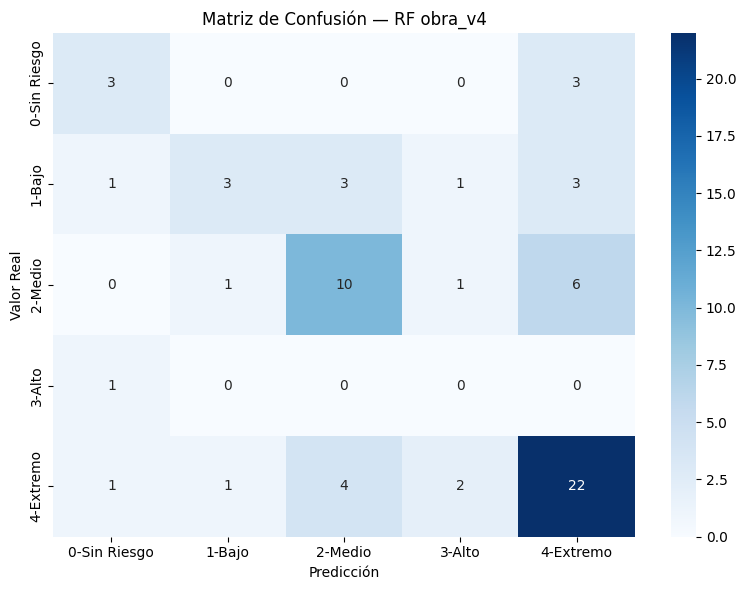

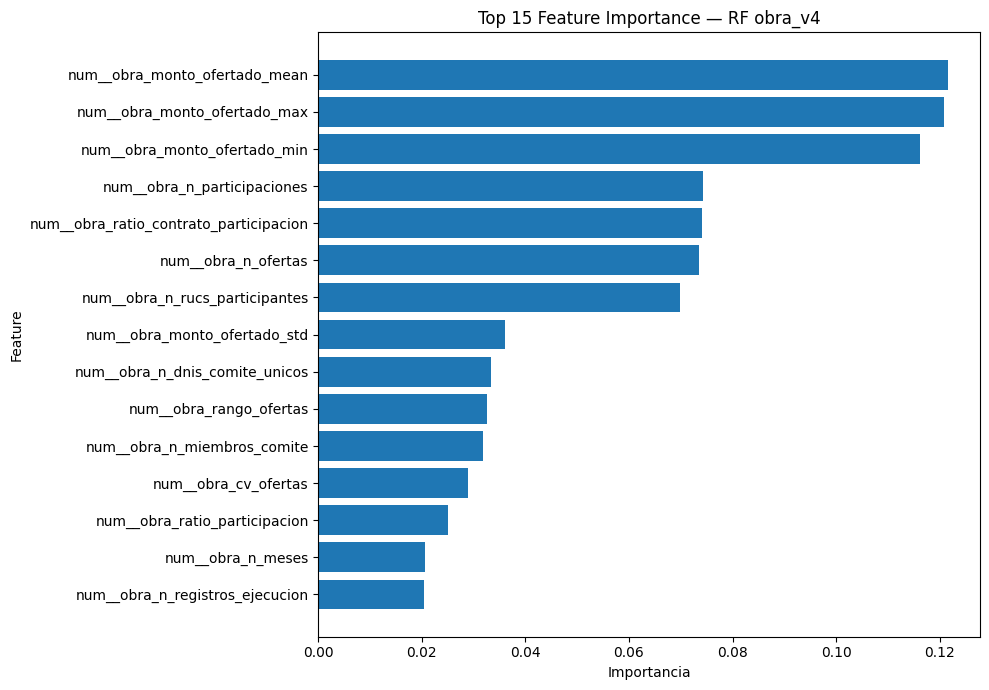

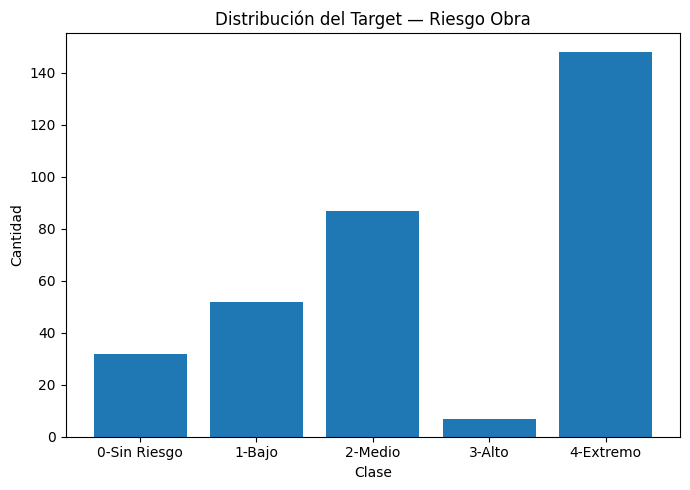

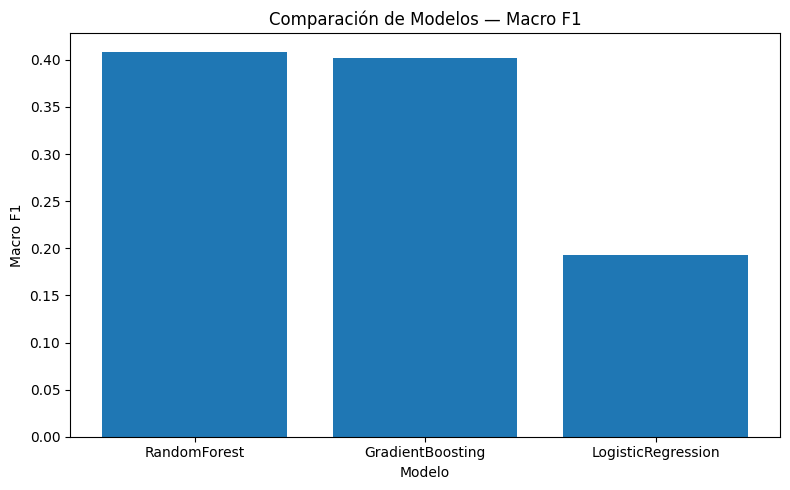

,feature,importance
12,num__obra_monto_ofertado_mean,0.121728
15,num__obra_monto_ofertado_max,0.120926
14,num__obra_monto_ofertado_min,0.116276
5,num__obra_n_participaciones,0.074385
11,num__obra_ratio_contrato_participacion,0.074177
16,num__obra_n_ofertas,0.073610
6,num__obra_n_rucs_participantes,0.069870
13,num__obra_monto_ofertado_std,0.035975
1,num__obra_n_dnis_comite_unicos,0.033346
17,num__obra_rango_ofertas,0.032518


In [38]:
# ============================================================
# PASO 12 — GRÁFICOS FINALES MODELO RF obra_v4
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Predicciones finales
# ------------------------------------------------------------

y_pred_final = final_model.predict(X_test)

# ------------------------------------------------------------
# Etiquetas clases
# ------------------------------------------------------------

class_labels = [
    "0-Sin Riesgo",
    "1-Bajo",
    "2-Medio",
    "3-Alto",
    "4-Extremo"
]

# ============================================================
# 1. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Matriz de Confusión — RF obra_v4")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.tight_layout()

plt.show()

# ============================================================
# 2. FEATURE IMPORTANCE TOP 15
# ============================================================

top_n = 15

top_features = importance_df.head(top_n)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top 15 Feature Importance — RF obra_v4")
plt.xlabel("Importancia")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# ============================================================
# 3. DISTRIBUCIÓN DEL TARGET
# ============================================================

target_counts = (
    y.value_counts()
    .sort_index()
)

plt.figure(figsize=(7,5))

plt.bar(
    class_labels,
    target_counts.values
)

plt.title("Distribución del Target — Riesgo Obra")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.tight_layout()

plt.show()

# ============================================================
# 4. COMPARACIÓN MODELOS
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df["modelo"],
    results_df["macro_f1"]
)

plt.title("Comparación de Modelos — Macro F1")
plt.xlabel("Modelo")
plt.ylabel("Macro F1")

plt.tight_layout()

plt.show()

# ============================================================
# 5. FEATURE IMPORTANCE EXPORT VISUAL
# ============================================================

display(top_features)